# Chapter 8: Acting in the Dark

The document appears ready, but the controller cannot directly see whether the hidden review state is valid. Acting on the most likely state may work, yet an additional observation could change which action is best. The observation's value comes from its effect on a decision, not from how detailed its text looks.

This notebook maintains a probability distribution over hidden states. It first predicts through a transition kernel, then updates with the observed signal. A separate calculation averages over every possible signal to price gathering information before acting. The changed case uses an observation that looks different on the surface but has identical state-conditioned distributions, exposing the difference between receiving data and learning something useful.

**Outcome:** Update a belief and calculate gross and net one-step information value.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

The predictive belief is b_minus(j)=sum_i b(i)P(j|i). For observation o, its probability is Z(o)=sum_j b_minus(j)O(o|j), and Bayes' rule gives b_plus(j)=b_minus(j)O(o|j)/Z(o). An observation with Z(o)=0 is impossible under the declared model and is rejected.

For reward vector r_a, acting now has value max_a sum_j b_minus(j)r_a(j). If the controller first observes, its gross expected decision value is sum_o Z(o) max_a sum_j b_plus_o(j)r_a(j). Gross value of information is the difference between that quantity and acting now. Net value subtracts the observation cost.

The maximum is taken after each possible observation because the action can adapt to the signal. Placing the maximum before averaging would price a fixed action and lose the decision benefit. An informative signal can still have zero value when it never changes the optimal action. Identical observation rows convey no state information at all. These are one-step values; the calculation does not solve a general partially observable planning problem.

## A calculation you can run

Provide a prior belief, transition matrix, observation matrix, reward vector for each action, observed index, and observation cost. Kernel dimensions must align, all probability rows must normalize, and the observed index must exist. The function predicts belief, evaluates the observation likelihood, forms its posterior, and selects the best posterior action.

It then repeats the posterior calculation for every possible observation to obtain information value. The first plot compares prior, predictive, and posterior probability of state zero. The second varies observation cost while holding gross benefit fixed. In the changed case, replace the observation rows with identical distributions. Predict both the posterior and information value before execution.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 8
inputs = {'belief': [0.5, 0.5],
 'transition': [[1, 0], [0, 1]],
 'observation': [[0.9, 0.1], [0.1, 0.9]],
 'observed': 0,
 'action_rewards': [[10, -10], [-10, 10]],
 'observation_cost': 1}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 8: belief-information
Should a controller act now or buy an observation before choosing?
Evidence: constructed teaching example

Calculated quantities:
{
  "predictive_belief": [
    0.5,
    0.5
  ],
  "posterior": [
    0.9,
    0.1
  ],
  "observed_probability": 0.5,
  "act_now_value": 0.0,
  "observe_then_act_value": 7.0,
  "gross_value_of_information": 8.0,
  "net_value_of_information": 7.0,
  "posterior_action": 0
}

Interpretation:
Bayes' rule updates the belief, while information value averages optimal later decisions over all possible observations.

Assumptions:
- Transition precedes observation.
- Information arrives before one decision.
- Observation incurs the declared cost.

Limitations:
- A likely observation is not necessarily useful; identical observation rows give no information.

Execution: completed locally; constructed inputs are not deployment measurements.


The default prior is equally split and the transition preserves it. Observation zero produces posterior [0.9,0.1]. Acting now has value zero because either action has equally weighted gains and losses. After observing, the controller can choose the appropriate action, giving expected value 8 before cost and 7 after cost.

The gross information value is therefore 8. With identical observation rows in the changed case, the posterior remains [0.5,0.5] regardless of the signal. Gross information value falls to zero and net information value becomes -1. The signal still arrives, but it does not earn its cost.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


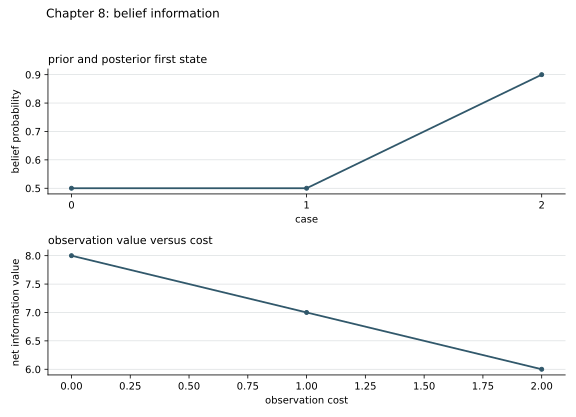

In [3]:
display(SVG(figure_svg(report)))

**Figure 8.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A belief update can be mathematically correct under an incorrect observation model. If a tool's signal changes distribution, or if hidden states were defined too coarsely, the posterior can look confident without being calibrated. Inspect the likelihood source rather than treating normalization as validation of the world model.

Information also has opportunity cost. The implemented cost is a single utility deduction; a deadline or state transition during observation would require a larger model. Likewise, this function assumes the same action set remains available after the observation.

An impossible signal should not be assigned an arbitrary uniform posterior. It is evidence that the declared boundary is incomplete or the input is inconsistent. The rejection asks you to repair that model rather than fabricate a belief. Preserve unmodeled outcomes in the next measurement design.

Chapter 8: belief-information
Should a controller act now or buy an observation before choosing?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "predictive_belief": [
    0.5,
    0.5
  ],
  "posterior": [
    0.5,
    0.5
  ],
  "observed_probability": 0.5,
  "act_now_value": 0.0,
  "observe_then_act_value": -1.0,
  "gross_value_of_information": 0.0,
  "net_value_of_information": -1.0,
  "posterior_action": 0
}

Interpretation:
Bayes' rule updates the belief, while information value averages optimal later decisions over all possible observations.

Assumptions:
- Transition precedes observation.
- Information arrives before one decision.
- Observation incurs the declared cost.

Limitations:
- A likely observation is not necessarily useful; identical observation rows give no information.

Execution: completed locally; constructed inputs are not deployment measurements.


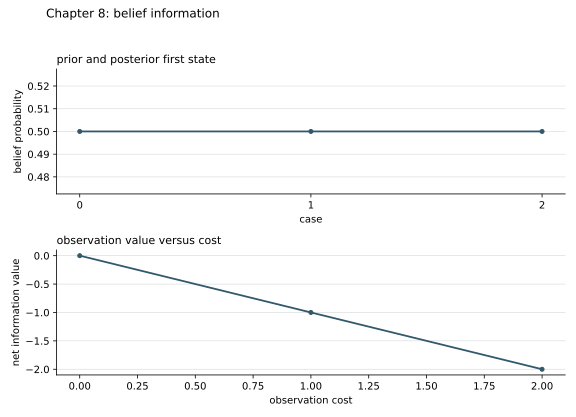

In [4]:
changed_inputs = {'belief': [0.5, 0.5],
 'transition': [[1, 0], [0, 1]],
 'observation': [[0.5, 0.5], [0.5, 0.5]],
 'observed': 0,
 'action_rewards': [[10, -10], [-10, 10]],
 'observation_cost': 1}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 8.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer case predicts a new belief before receiving observation one. Its transition mixes the initial states, so the prior is not the correct distribution to insert directly into Bayes' rule. First calculate the predictive belief [0.6,0.4], then weight it by observation-one likelihoods [0.2,0.7] and normalize.

Use local data only when the state, observation, and action definitions share one boundary. If likelihoods are fitted estimates, retain their sample sizes and calibration limits outside this exact calculation. Report gross information value separately from cost so a negative net result can be traced to unhelpful evidence, high price, or both.

In [5]:
transfer_inputs = {'belief': [0.8, 0.2],
 'transition': [[0.7, 0.3], [0.2, 0.8]],
 'observation': [[0.8, 0.2], [0.3, 0.7]],
 'observed': 1,
 'action_rewards': [[5, -4], [0, 2]],
 'observation_cost': 0.2}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 8: belief-information
Should a controller act now or buy an observation before choosing?
Evidence: constructed transfer example

Calculated quantities:
{
  "predictive_belief": [
    0.6,
    0.4
  ],
  "posterior": [
    0.3,
    0.7
  ],
  "observed_probability": 0.4,
  "act_now_value": 1.4,
  "observe_then_act_value": 2.28,
  "gross_value_of_information": 1.08,
  "net_value_of_information": 0.88,
  "posterior_action": 1
}

Interpretation:
Bayes' rule updates the belief, while information value averages optimal later decisions over all possible observations.

Assumptions:
- Transition precedes observation.
- Information arrives before one decision.
- Observation incurs the declared cost.

Limitations:
- A likely observation is not necessarily useful; identical observation rows give no information.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **belief:** Normalized prior state probability list.
- **transition:** Square row-stochastic state transition matrix.
- **observation:** State by observation row-stochastic matrix.
- **observed:** Zero-based observation index.
- **action_rewards:** Action by state finite reward matrix.
- **observation_cost:** Nonnegative cost paid before the one later action.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch08.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 8: belief-information
Should a controller act now or buy an observation before choosing?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "predictive_belief": [
    0.6,
    0.4
  ],
  "posterior": [
    0.3,
    0.7
  ],
  "observed_probability": 0.4,
  "act_now_value": 1.4,
  "observe_then_act_value": 2.28,
  "gross_value_of_information": 1.08,
  "net_value_of_information": 0.88,
  "posterior_action": 1
}

Interpretation:
Bayes' rule updates the belief, while information value averages optimal later decisions over all possible observations.

Assumptions:
- Transition precedes observation.
- Information arrives before one decision.
- Observation incurs the declared cost.

Limitations:
- A likely observation is not necessarily useful; identical observation rows give no information.

Execution: completed locally; constructed inputs are not deployment measurements.


## Questions

1. Compute default posterior.

2. What observation cost makes default information break even?

3. Compute transfer posterior after observation 1.

Answers: [separate solutions](../solutions/ch08.md). Try the calculation before opening them.

## Summary

Beliefs predict through transitions and update through observation likelihoods. Information is worth its decision improvement after cost, not its volume or apparent specificity. The default signal changes the optimal action; the changed signal is uninformative; the transfer case requires transition prediction before Bayes' rule. Keep normalization, model provenance, and action timing explicit. This notebook prices one observation and one decision within a declared hidden-state model.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-08-belief-information`](../skills/maa-08-belief-information/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 8.1

![Equation 8.1](../assets/math/e992bac4f67c2b9f4efc.svg)

Equation (8.1) turns yesterday's belief, one action, and one observation into today's belief.

Push the old belief forward through the action, weight each destination by how well it explains what was seen, then rescale so the weights sum to one.

LaTeX source, preserved for inspection:

```latex
\mathbf{b}_{t+1}(x') \;=\;
\frac{\begin{gathered}
\operatorname{Obs}(o\mid x',a)\\
\cdot\sum_{x\in\mathcal{X}}P(x'\mid x,a)\,\mathbf{b}_t(x)
\end{gathered}}
{\begin{gathered}
\sum_{x''\in\mathcal{X}}\operatorname{Obs}(o\mid x'',a)\\
\cdot\sum_{x\in\mathcal{X}}P(x''\mid x,a)\,\mathbf{b}_t(x)
\end{gathered}}.
\tag{8.1}
```

### Equation un-numbered display 2

![Equation un-numbered display 2](../assets/math/aeaa392b80c6a5400cb4.svg)



LaTeX source, preserved for inspection:

```latex
T_E=\begin{pmatrix}
0.1&0.9&0&0\\
0.1&0&0.9&0\\
0&0.1&0&0.9\\
0&0&0.1&0.9
\end{pmatrix},\qquad
\operatorname{Obs}(\text{non-goal}\mid x')=(1,1,0,1).
```

### Equation 8.2

![Equation 8.2](../assets/math/c2b31b3a9ae02b649313.svg)

Equation (8.2) prices an action under uncertainty about where the agent is.

Average the reward the action would earn in each state, weighting each state by how much belief sits on it.

LaTeX source, preserved for inspection:

```latex
\bar r(\mathbf{b},a)\;=\;\sum_{x\in\mathcal{X}}\mathbf{b}(x)\,r(x,a).
\tag{8.2}
```

### Equation 8.3

![Equation 8.3](../assets/math/cd4610a982670be0201e.svg)

Equation (8.3) values a belief by the best action available from it and the beliefs that action can lead to.

Take the immediate expected reward, add the discounted average value of the belief each possible observation would produce, and keep the best action.

LaTeX source, preserved for inspection:

```latex
\begin{aligned}
V(\mathbf{b})
&=\max_{a\in\mathcal{A}}\Big[\,\bar r(\mathbf{b},a)\\
&\quad+\gamma\sum_{o}\Pr(o\mid \mathbf{b},a)\,
V\big(\mathbf{b}'(\mathbf{b},a,o)\big)\Big].
\end{aligned}
\tag{8.3}
```

### Equation 8.4

![Equation 8.4](../assets/math/a29d857519b0a313b7c7.svg)

Equation (8.4) represents finite-horizon belief value as best dot product from finite policy-vector set.

Score each contingent plan against current belief, then select largest expected return.

LaTeX source, preserved for inspection:

```latex
V_H(\mathbf b)=\max_{\alpha\in\Gamma_H}\alpha^\top\mathbf b.
\tag{8.4}
```

### Equation 8.5

![Equation 8.5](../assets/math/56c0b286f79d620e6ec3.svg)

Equation (8.5) prices a look by how much better the decision becomes once its answer is known.

Average the best achievable reward across the beliefs each possible answer would leave, then subtract the best achievable reward without looking.

LaTeX source, preserved for inspection:

```latex
\begin{aligned}
\operatorname{VOI}(O)
&=\sum_{o}\Pr(o\mid\mathbf{b})\,
\max_{a\in\mathcal{A}}\bar r\big(\mathbf{b}'(\mathbf{b},o),a\big)\\
&\quad-\max_{a\in\mathcal{A}}\bar r(\mathbf{b},a).
\end{aligned}
\tag{8.5}
```